# HAR com Sinais Brutos — CNN 1D para TinyML (4 classes)
**Dataset:** UCI Human Activity Recognition Using Smartphones  
**Abordagem:** Sinais brutos dos sensores inerciais (sem features pré-calculadas)  
**Plataforma alvo:** Raspberry Pi Pico (RP2040)

---

## Por que sinais brutos?

O dataset UCI-HAR fornece 561 features pré-calculadas, mas muitas delas exigem FFT
para serem computadas — inviável no RP2040. Treinando diretamente com os 9 canais
de sinal bruto (128 amostras × 9 canais), a CNN aprende os padrões temporais
diretamente, e o embarcado só precisa coletar as amostras e rodar a inferência.

**Classes utilizadas:** este notebook foi adaptado para classificar **4 atividades**
(WALKING, SITTING, STANDING, LAYING), removendo WALKING_UPSTAIRS e WALKING_DOWNSTAIRS
do conjunto original do UCI-HAR — adequado ao escopo do projeto embarcado na Pico + MPU6050.

## Estrutura do Notebook

| Seção | Conteúdo |
|:---:|:---|
| 1 | Configuração: importações e constantes |
| 2 | Coleta e carregamento dos sinais brutos |
| 3 | Análise exploratória dos sinais |
| 4 | Pré-processamento e normalização |
| 5 | Definição da CNN 1D |
| 6 | Treinamento |
| 7 | Avaliação com métricas completas |
| 8 | Quantização e exportação para TFLite |
| 9 | Resumo final |

---
## Seção 1 — Configuração: Importações e Constantes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler

# ── Constantes ─────────────────────────────────────────────
PATH_DATASET  = 'UCI HAR Dataset/'
NUM_CLASSES   = 4   # ajustado: 4 classes (sem WALKING_UPSTAIRS / WALKING_DOWNSTAIRS)
WINDOW_SIZE   = 128   # amostras por janela
N_CHANNELS    = 9     # canais inerciais brutos
SAMPLE_RATE   = 50    # Hz

# Mapa das classes finais (após remoção de WALKING_UP e WALKING_DOWN)
ACTIVITY_MAP = {
    0: 'WALKING',
    1: 'SITTING',
    2: 'STANDING',
    3: 'LAYING',
}

# Classes originais do UCI-HAR que serão mantidas (rótulos 0-indexados)
# Original: 0=WALKING 1=WALKING_UP 2=WALKING_DOWN 3=SITTING 4=STANDING 5=LAYING
CLASSES_ORIGINAIS_MANTIDAS = [0, 3, 4, 5]

# Remapeamento: rótulo original -> novo rótulo (0..3)
REMAP_LABELS = {orig: novo for novo, orig in enumerate(CLASSES_ORIGINAIS_MANTIDAS)}

CHANNEL_NAMES = [
    'body_acc_x',  'body_acc_y',  'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z',
]

COLORS = {
    'acc'  : '#3266ad',
    'gyro' : '#e8a838',
    'total': '#2ecc71',
}

print(f'TensorFlow : {tf.__version__}')
print(f'GPU disponível: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Janela     : {WINDOW_SIZE} amostras  ({WINDOW_SIZE/SAMPLE_RATE:.2f} s)')
print(f'Canais     : {N_CHANNELS}')

TensorFlow : 2.20.0
GPU disponível: True
Janela     : 128 amostras  (2.56 s)
Canais     : 9


---
## Seção 2 — Coleta e Carregamento dos Sinais Brutos

### 2.1 Estrutura dos arquivos de sinal bruto

```
UCI HAR Dataset/
├── train/
│   ├── y_train.txt                     ← rótulos
│   └── Inertial Signals/
│       ├── body_acc_x_train.txt        ← aceleração corporal eixo X
│       ├── body_acc_y_train.txt
│       ├── body_acc_z_train.txt
│       ├── body_gyro_x_train.txt       ← velocidade angular eixo X
│       ├── body_gyro_y_train.txt
│       ├── body_gyro_z_train.txt
│       ├── total_acc_x_train.txt       ← aceleração total eixo X
│       ├── total_acc_y_train.txt
│       └── total_acc_z_train.txt
└── test/
    └── Inertial Signals/  (mesma estrutura)
```

Cada arquivo tem shape **(amostras, 128)** — cada linha é uma janela de 128 leituras.  
Empilhando os 9 canais: shape final **(amostras, 128, 9)**.

### 2.2 Download

In [ ]:
if not os.path.exists(PATH_DATASET):
    print('⬇ Baixando dataset...')
    !wget -q "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
    !unzip -q "human+activity+recognition+using+smartphones.zip"
    !unzip -q "UCI HAR Dataset.zip"
    print('✓ Dataset extraído.')
else:
    print('✓ Dataset já disponível.')

⬇ Baixando dataset...
✓ Dataset extraído.


### 2.3 Função de carregamento dos sinais brutos

In [ ]:
def carregar_sinais_brutos(path, conjunto):
    """
    Carrega os 9 canais de sinal bruto e empilha em um tensor 3D.

    Retorna
    -------
    X : np.ndarray  shape (amostras, 128, 9)  float32
    y : np.ndarray  shape (amostras,)          int  [0..5]
    """
    sinais = []
    for canal in CHANNEL_NAMES:
        arquivo = f"{path}/{conjunto}/Inertial Signals/{canal}_{conjunto}.txt"
        dados = np.loadtxt(arquivo)          # (amostras, 128)
        sinais.append(dados)

    X = np.stack(sinais, axis=2).astype('float32')   # (amostras, 128, 9)

    y_path = f"{path}/{conjunto}/y_{conjunto}.txt"
    y = np.loadtxt(y_path).astype(int) - 1           # 1-6  →  0-5

    return X, y


print('Carregando sinais de treino...')
X_train, y_train = carregar_sinais_brutos(PATH_DATASET, 'train')

print('Carregando sinais de teste...')
X_test, y_test = carregar_sinais_brutos(PATH_DATASET, 'test')

print(f'\nShapes carregados:')
print(f'  X_train : {X_train.shape}   dtype: {X_train.dtype}')
print(f'  y_train : {y_train.shape}')
print(f'  X_test  : {X_test.shape}    dtype: {X_test.dtype}')
print(f'  y_test  : {y_test.shape}')
print(f'\nSignificado de cada dimensão: (amostras, timesteps, canais)')
print(f'  {X_train.shape[0]} janelas  ×  {X_train.shape[1]} amostras  ×  {X_train.shape[2]} canais')

Carregando sinais de treino...
Carregando sinais de teste...

Shapes carregados:
  X_train : (7352, 128, 9)   dtype: float32
  y_train : (7352,)
  X_test  : (2947, 128, 9)    dtype: float32
  y_test  : (2947,)

Significado de cada dimensão: (amostras, timesteps, canais)
  7352 janelas  ×  128 amostras  ×  9 canais


### 2.4 Filtragem para 4 classes

O dataset original do UCI-HAR tem 6 atividades. Para este projeto (TinyML na Raspberry Pi Pico
com MPU6050) vamos **remover WALKING_UPSTAIRS e WALKING_DOWNSTAIRS**, mantendo apenas:

- `WALKING`
- `SITTING`
- `STANDING`
- `LAYING`

As amostras das classes removidas são descartadas de `X_train`/`y_train` e `X_test`/`y_test`,
e os rótulos remanescentes são remapeados para o intervalo `0..3` (necessário para o
`to_categorical` e para a camada de saída `Dense(NUM_CLASSES)`).

In [ ]:
# Filtra apenas as 4 classes de interesse e remapeia os rótulos para 0..3
def filtrar_e_remapear(X, y, classes_mantidas, remap):
    mask = np.isin(y, classes_mantidas)
    X_filt = X[mask]
    y_filt = y[mask]
    y_filt = np.array([remap[label] for label in y_filt], dtype=int)
    return X_filt, y_filt

print(f'Antes do filtro -> X_train: {X_train.shape}  X_test: {X_test.shape}')

X_train, y_train = filtrar_e_remapear(X_train, y_train, CLASSES_ORIGINAIS_MANTIDAS, REMAP_LABELS)
X_test,  y_test  = filtrar_e_remapear(X_test,  y_test,  CLASSES_ORIGINAIS_MANTIDAS, REMAP_LABELS)

print(f'Depois do filtro -> X_train: {X_train.shape}  X_test: {X_test.shape}')
print(f'\nClasses finais: {ACTIVITY_MAP}')
print(f'Rótulos únicos (treino): {sorted(np.unique(y_train).tolist())}')
print(f'Rótulos únicos (teste) : {sorted(np.unique(y_test).tolist())}')


Antes do filtro -> X_train: (7352, 128, 9)  X_test: (2947, 128, 9)
Depois do filtro -> X_train: (5293, 128, 9)  X_test: (2056, 128, 9)

Classes finais: {0: 'WALKING', 1: 'SITTING', 2: 'STANDING', 3: 'LAYING'}
Rótulos únicos (treino): [0, 1, 2, 3]
Rótulos únicos (teste) : [0, 1, 2, 3]


---
## Seção 3 — Análise Exploratória dos Sinais

### 3.1 Estatísticas básicas e verificação de qualidade

In [ ]:
print('═' * 50)
print('  VERIFICAÇÃO DE QUALIDADE')
print('═' * 50)
print(f'  Valores NaN (treino) : {np.isnan(X_train).sum()}')
print(f'  Valores NaN (teste)  : {np.isnan(X_test).sum()}')
print(f'  Valor máximo (treino): {X_train.max():.4f}')
print(f'  Valor mínimo (treino): {X_train.min():.4f}')
print('═' * 50)

# Estatísticas por canal
print('\nEstatísticas por canal (treino):')
print(f'  {"Canal":<18} {"Média":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('  ' + '-'*50)
for i, nome in enumerate(CHANNEL_NAMES):
    canal = X_train[:, :, i].ravel()
    print(f'  {nome:<18} {canal.mean():>8.4f} {canal.std():>8.4f} '
          f'{canal.min():>8.4f} {canal.max():>8.4f}')

══════════════════════════════════════════════════
  VERIFICAÇÃO DE QUALIDADE
══════════════════════════════════════════════════
  Valores NaN (treino) : 0
  Valores NaN (teste)  : 0
  Valor máximo (treino): 4.7364
  Valor mínimo (treino): -4.4779
══════════════════════════════════════════════════

Estatísticas por canal (treino):
  Canal                 Média      Std      Min      Max
  --------------------------------------------------
  body_acc_x          -0.0006   0.1121  -1.2322   1.0445
  body_acc_y           0.0005   0.0881  -0.9982   0.7665
  body_acc_z           0.0003   0.0747  -0.9629   0.7918
  body_gyro_x         -0.0000   0.2530  -3.6447   4.1555
  body_gyro_y         -0.0006   0.2721  -4.4779   4.7364
  body_gyro_z          0.0029   0.1727  -1.5897   1.6657
  total_acc_x          0.7406   0.4275  -0.4666   2.0453
  total_acc_y          0.1230   0.4036  -1.2641   1.2174
  total_acc_z          0.1621   0.3659  -1.1572   1.2814


### 3.2 Visualização dos sinais por atividade

Cada linha mostra os 3 eixos de um mesmo grupo de sensor (aceleração corporal, giroscópio, aceleração total) para uma amostra de cada atividade.

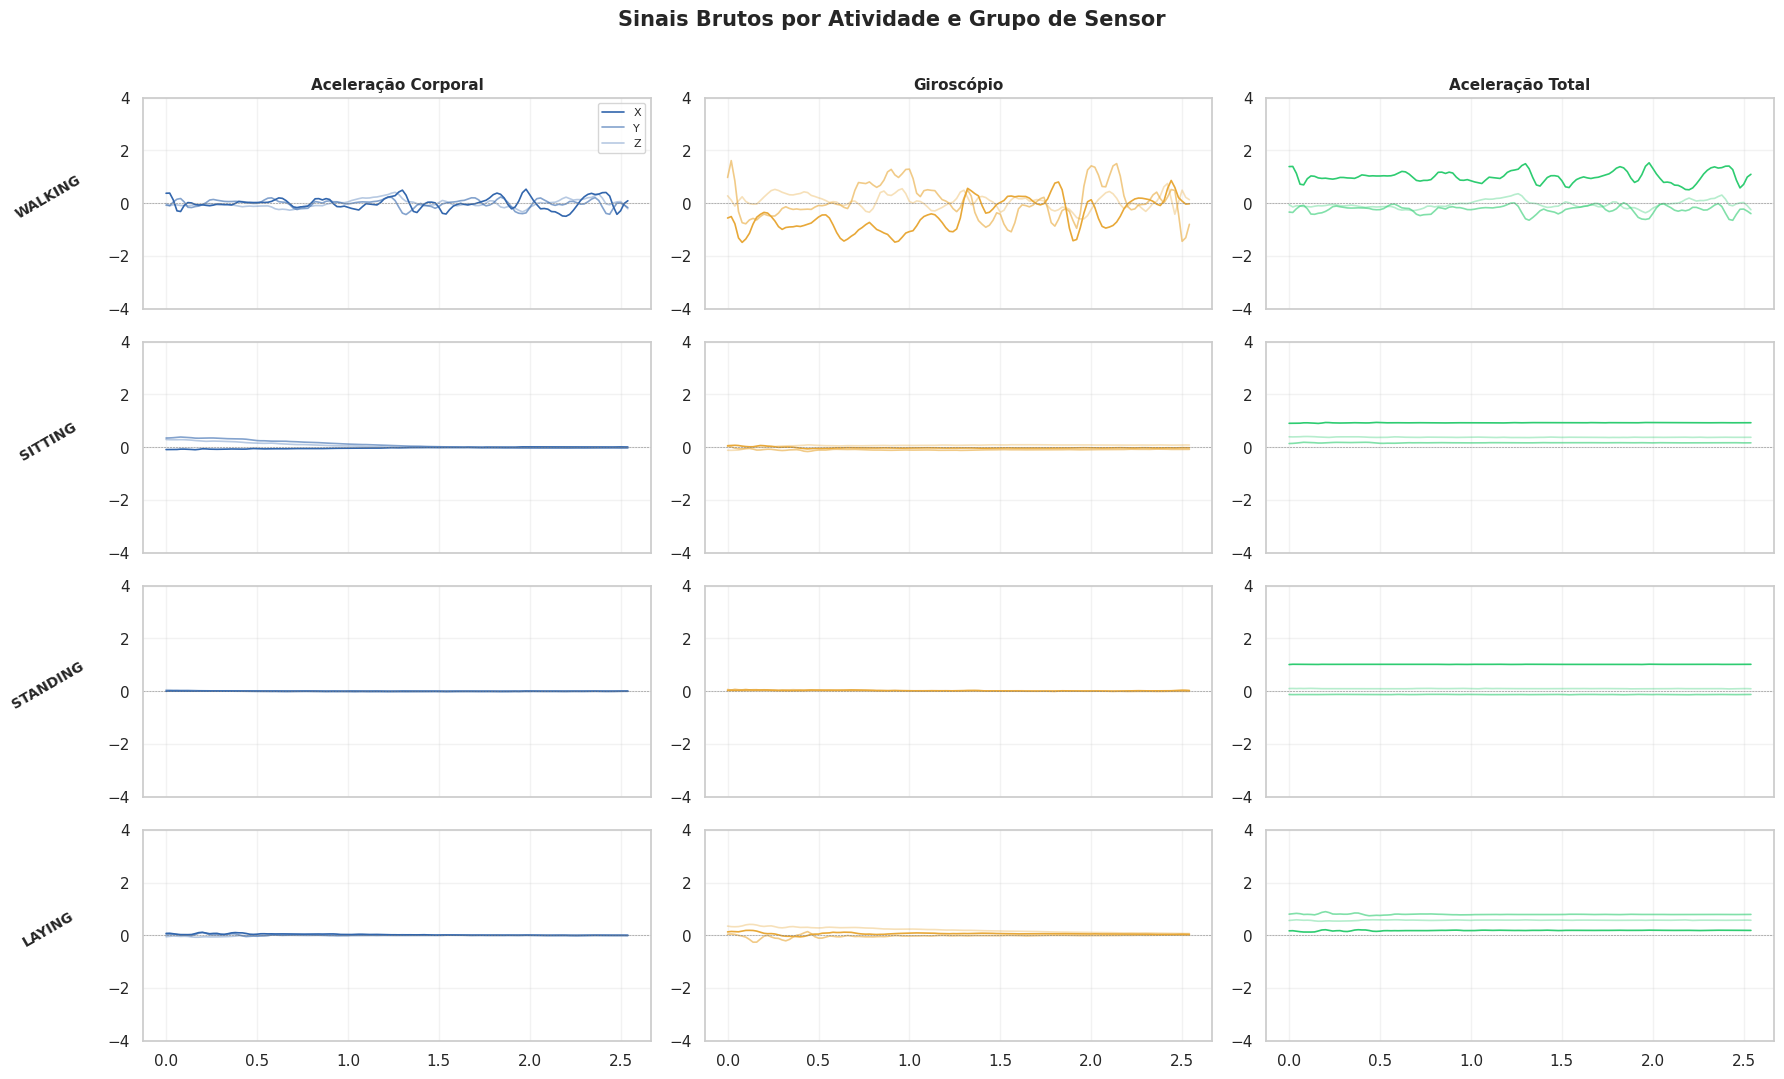

In [ ]:
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(18, 16 * NUM_CLASSES / 6), sharex=True)
t = np.arange(WINDOW_SIZE) / SAMPLE_RATE   # eixo de tempo em segundos

grupos = [
    ('Aceleração Corporal', [0, 1, 2], COLORS['acc']),
    ('Giroscópio',          [3, 4, 5], COLORS['gyro']),
    ('Aceleração Total',    [6, 7, 8], COLORS['total']),
]
eixos_label = ['X', 'Y', 'Z']

for row, (label_ativ, idx_ativ) in enumerate(ACTIVITY_MAP.items()):
    idx_amostra = np.where(y_train == row)[0][0]
    sinal = X_train[idx_amostra]   # (128, 9)

    for col, (grupo_nome, canais_idx, cor) in enumerate(grupos):
        ax = axes[row, col]
        for k, ch in enumerate(canais_idx):
            ax.plot(t, sinal[:, ch],
                    label=eixos_label[k],
                    color=cor,
                    alpha=[1.0, 0.6, 0.35][k],
                    linewidth=1.2)
        ax.axhline(0, color='gray', linewidth=0.4, linestyle='--')
        ax.set_ylim(-4, 4)
        ax.grid(alpha=0.25)
        if row == 0:
            ax.set_title(grupo_nome, fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(idx_ativ, fontsize=10, fontweight='bold', rotation=30, labelpad=40)
        if row == 5:
            ax.set_xlabel('Tempo (s)')
        if row == 0 and col == 0:
            ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Sinais Brutos por Atividade e Grupo de Sensor', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Distribuição das classes

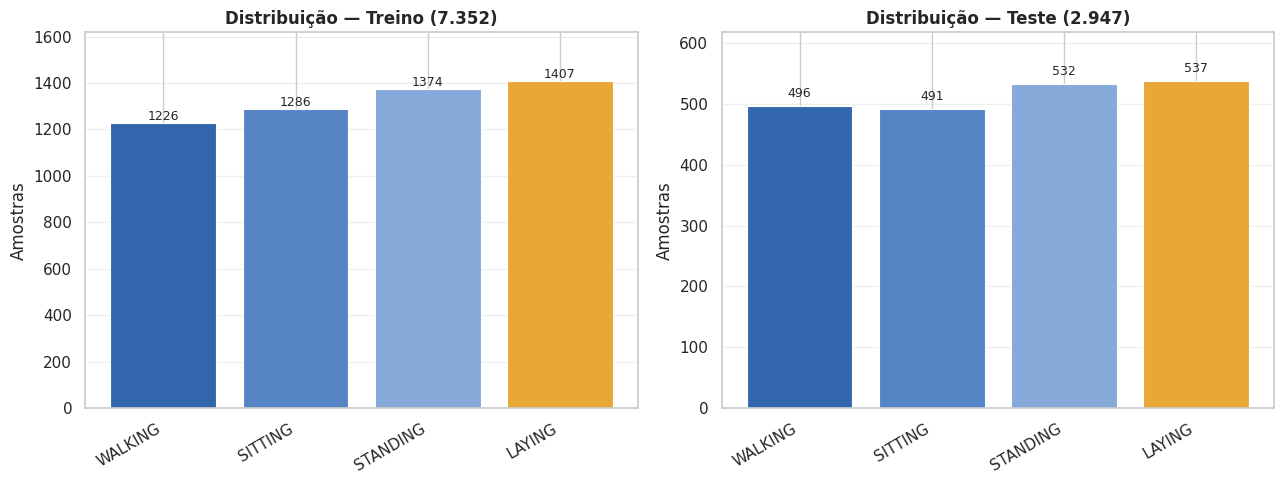

Ratio de desbalanceamento (treino): 1.15:1  →  leve


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y, titulo) in zip(axes, [(y_train, 'Treino (7.352)'), (y_test, 'Teste (2.947)')]):
    contagem = np.bincount(y)
    labels   = [ACTIVITY_MAP[i] for i in range(NUM_CLASSES)]
    bars = ax.bar(labels, contagem,
                  color=['#3266ad','#5585c5','#85a9d9','#e8a838','#f0c070','#2ecc71'],
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, contagem):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 15, str(val),
                ha='center', fontsize=9)
    ax.set_title(f'Distribuição — {titulo}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Amostras')
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylim(0, contagem.max() * 1.15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

ratio = y_train.__len__() and np.bincount(y_train).max() / np.bincount(y_train).min()
print(f'Ratio de desbalanceamento (treino): {ratio:.2f}:1  →  leve')

---
## Seção 4 — Pré-processamento e Normalização

### Por que normalizar os sinais brutos?

Os canais de aceleração e giroscópio têm escalas diferentes:
- Aceleração: valores em torno de ±2g (~±19.6 m/s²)
- Giroscópio:  valores em rad/s, escala diferente

Normalizar canal por canal garante que nenhum grupo de sensor domine o aprendizado
por ter amplitude maior. Usamos **StandardScaler por canal** — media zero, std 1.

> O scaler é ajustado APENAS no treino e aplicado ao teste.
> Isso evita vazamento de informação (data leakage).

In [ ]:
# Normalização por canal (StandardScaler canal a canal)
# X shape: (amostras, 128, 9)
# Reshape para (amostras*128, 9) → fit → reshape de volta

n_train = X_train.shape[0]
n_test  = X_test.shape[0]

# Achatar para 2D, normalizar, restaurar 3D
X_train_flat = X_train.reshape(-1, N_CHANNELS)   # (n*128, 9)
X_test_flat  = X_test.reshape(-1, N_CHANNELS)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_flat).reshape(n_train, WINDOW_SIZE, N_CHANNELS)
X_test_norm  = scaler.transform(X_test_flat).reshape(n_test,  WINDOW_SIZE, N_CHANNELS)

X_train_norm = X_train_norm.astype('float32')
X_test_norm  = X_test_norm.astype('float32')

# One-hot encoding das labels
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

# Verificação
print('Após normalização:')
print(f'  X_train_norm : {X_train_norm.shape}  média={X_train_norm.mean():.4f}  std={X_train_norm.std():.4f}')
print(f'  X_test_norm  : {X_test_norm.shape}   média={X_test_norm.mean():.4f}  std={X_test_norm.std():.4f}')
print(f'  y_train_oh   : {y_train_oh.shape}')

# Parâmetros do scaler salvos para uso no firmware
print(f'\nParâmetros do scaler (necessários no firmware):')
print(f'  mean_ por canal: {scaler.mean_.round(4)}')
print(f'  scale_ por canal: {scaler.scale_.round(4)}')

Após normalização:
  X_train_norm : (5293, 128, 9)  média=-0.0000  std=1.0000
  X_test_norm  : (2056, 128, 9)   média=-0.0092  std=0.9643
  y_train_oh   : (5293, 4)

Parâmetros do scaler (necessários no firmware):
  mean_ por canal: [-6.000e-04  5.000e-04  3.000e-04 -0.000e+00 -6.000e-04  2.900e-03
  7.406e-01  1.230e-01  1.621e-01]
  scale_ por canal: [0.1121 0.0881 0.0747 0.253  0.2721 0.1727 0.4275 0.4036 0.3659]


---
## Seção 5 — Definição da CNN 1D para Sinais Brutos

### Arquitetura

Com sinais brutos de entrada `(128, 9)` a CNN pode usar kernels maiores para
capturar padrões temporais mais longos — diferente da abordagem com features
tabulares onde usávamos kernel=3 em 60 posições.

| Camada | Configuração | Justificativa |
|:---|:---|:---|
| Conv1D(64, kernel=5) | 64 filtros, janela de 5 amostras (0,1 s) | Captura padrões locais curtos |
| Conv1D(128, kernel=5) | 128 filtros | Combina padrões do bloco anterior |
| Conv1D(128, kernel=3) | 128 filtros, kernel menor | Refina representação |
| GlobalAvgPooling1D | — | Agrega ao longo do tempo, compacto para TinyML |
| Dense(64) + Dropout(0.4) | Camada densa intermediária | Aprende combinações de alto nível |
| Dense(4, Softmax) | Saída | Uma probabilidade por atividade (4 classes) |

In [ ]:
def build_cnn_raw(input_shape=(WINDOW_SIZE, N_CHANNELS), num_classes=NUM_CLASSES):
    """
    CNN 1D para sinais brutos inerciais.
    Entrada: (128 timesteps, 9 canais)
    Saída  : (6 classes)
    """
    inputs = keras.Input(shape=input_shape, name='raw_signal')

    # ── Bloco 1: padrões locais curtos ───────────────────────
    x = layers.Conv1D(64, kernel_size=5, padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)   # 128 → 64

    # ── Bloco 2: padrões de médio alcance ────────────────────
    x = layers.Conv1D(128, kernel_size=5, padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)   # 64 → 32

    # ── Bloco 3: refinamento ─────────────────────────────────
    x = layers.Conv1D(128, kernel_size=3, padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)

    # ── Cabeça classificadora ────────────────────────────────
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(64, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.4, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='CNN1D_RAW_HAR')
    return model


model = build_cnn_raw()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

model.summary()

# Tamanho estimado antes de quantizar
params = model.count_params()
print(f'\nParâmetros totais : {params:,}')
print(f'Tamanho float32   : {params * 4 / 1024:.1f} KB')

Model: "CNN1D_RAW_HAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_signal (InputLayer)         │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 128, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 64, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 32, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 32, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,108 (402.77 KB)

 Trainable params: 102,468 (400.27 KB)

 Non-trainable params: 640 (2.50 KB)


Parâmetros totais : 103,108
Tamanho float32   : 402.8 KB


---
## Seção 6 — Treinamento

### Hiperparâmetros

| Parâmetro | Valor | Justificativa |
|:---|:---:|:---|
| Épocas | 60 | Sinais brutos precisam de mais épocas que features tabulares |
| Batch size | 64 | Equilíbrio velocidade/generalização |
| EarlyStopping | patience=10 | Mais paciente que antes — sinais brutos convergem mais devagar |
| ReduceLROnPlateau | patience=5, factor=0.5 | Refina convergência |

In [ ]:
EPOCHS     = 60
BATCH_SIZE = 64

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train_norm, y_train_oh,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_norm, y_test_oh),
    callbacks=[cb_early_stop, cb_reduce_lr],
    verbose=1
)

print('\nTreinamento concluído!')

Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.8929 - loss: 0.2920 - precision: 0.9157 - recall: 0.8643 - val_accuracy: 0.9066 - val_loss: 0.2376 - val_precision: 0.9185 - val_recall: 0.8988 - learning_rate: 0.0010
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9276 - loss: 0.1878 - precision: 0.9288 - recall: 0.9263 - val_accuracy: 0.9086 - val_loss: 0.2079 - val_precision: 0.9085 - val_recall: 0.9081 - learning_rate: 0.0010
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9314 - loss: 0.1739 - precision: 0.9320 - recall: 0.9301 - val_accuracy: 0.9115 - val_loss: 0.2085 - val_precision: 0.9128 - val_recall: 0.9115 - learning_rate: 0.0010
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9331 - loss: 0.1580 - precision: 0.9346 - recall: 0.9318 - val_accuracy: 0.9100 - val_loss: 0.2260 - val_precision: 0.9105 - val_recall: 0.9100 - learning_rate: 0.0010
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9293 -

### 6.1 Curvas de aprendizado

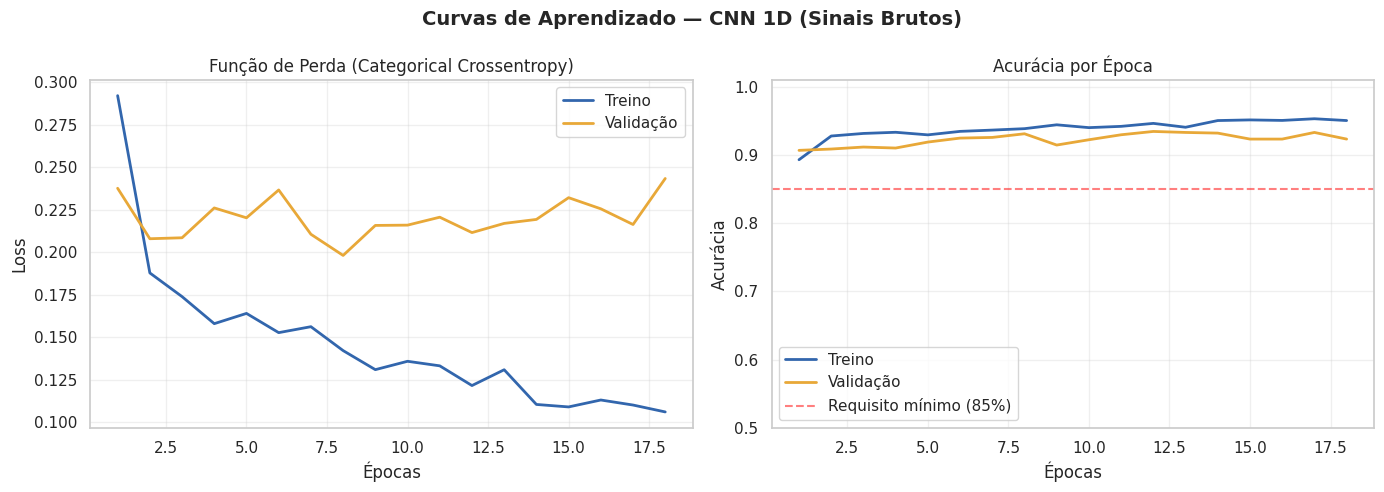

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epocas = range(1, len(history.history['loss']) + 1)

# Perda
axes[0].plot(epocas, history.history['loss'],     label='Treino',    color='#3266ad', linewidth=2)
axes[0].plot(epocas, history.history['val_loss'], label='Validação', color='#e8a838', linewidth=2)
axes[0].set_title('Função de Perda (Categorical Crossentropy)', fontsize=12)
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Acurácia
axes[1].plot(epocas, history.history['accuracy'],     label='Treino',    color='#3266ad', linewidth=2)
axes[1].plot(epocas, history.history['val_accuracy'], label='Validação', color='#e8a838', linewidth=2)
axes[1].axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Requisito mínimo (85%)')
axes[1].set_title('Acurácia por Época', fontsize=12)
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Acurácia')
axes[1].set_ylim(0.5, 1.01)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizado — CNN 1D (Sinais Brutos)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Seção 7 — Avaliação com Métricas Completas

In [ ]:
# Predições
y_pred_prob = model.predict(X_test_norm, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test

class_names = [ACTIVITY_MAP[i] for i in range(NUM_CLASSES)]

# ── Métricas globais ──────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

print('=' * 50)
print('     MÉTRICAS GLOBAIS (weighted)')
print('=' * 50)
print(f'  Acurácia  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precisão  : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-score  : {f1:.4f}')
print('=' * 50)
req_acc = '✓ ATENDIDO' if acc >= 0.85 else '✗ NÃO ATENDIDO'
print(f'  RNF4 (≥85%): {req_acc}')
print('=' * 50)

print('\nRELATÓRIO POR CLASSE:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

     MÉTRICAS GLOBAIS (weighted)
  Acurácia  : 0.9309  (93.09%)
  Precisão  : 0.9308
  Recall    : 0.9309
  F1-score  : 0.9308
  RNF4 (≥85%): ✓ ATENDIDO

RELATÓRIO POR CLASSE:
              precision    recall  f1-score   support

     WALKING     0.9980    1.0000    0.9990       496
     SITTING     0.8674    0.8391    0.8530       491
    STANDING     0.8606    0.8816    0.8709       532
      LAYING     0.9963    1.0000    0.9981       537

    accuracy                         0.9309      2056
   macro avg     0.9305    0.9302    0.9303      2056
weighted avg     0.9308    0.9309    0.9308      2056



### 7.1 Matriz de confusão

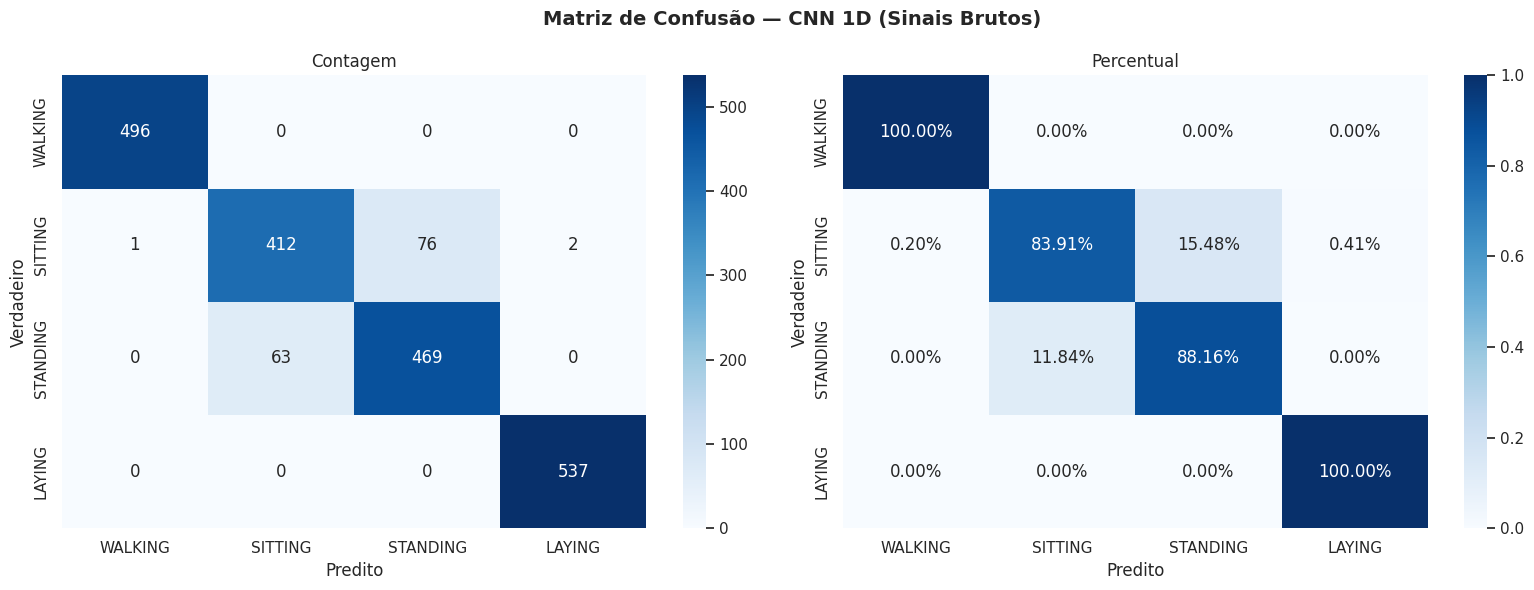


Diagnóstico SITTING vs STANDING:
  SITTING  classificado corretamente : 83.9%
  STANDING classificado corretamente : 88.2%
  SITTING  confundido com STANDING   : 15.5%
  STANDING confundido com SITTING    : 11.8%


In [ ]:
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Contagem', fontsize=12)
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Verdadeiro')

sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Percentual', fontsize=12)
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Verdadeiro')

plt.suptitle('Matriz de Confusão — CNN 1D (Sinais Brutos)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Diagnóstico SITTING vs STANDING (índices localizados dinamicamente no ACTIVITY_MAP)
idx_sitting  = [k for k, v in ACTIVITY_MAP.items() if v == 'SITTING'][0]
idx_standing = [k for k, v in ACTIVITY_MAP.items() if v == 'STANDING'][0]

sitting_correto  = cm_pct[idx_sitting, idx_sitting] * 100
standing_correto = cm_pct[idx_standing, idx_standing] * 100
print(f'\nDiagnóstico SITTING vs STANDING:')
print(f'  SITTING  classificado corretamente : {sitting_correto:.1f}%')
print(f'  STANDING classificado corretamente : {standing_correto:.1f}%')
print(f'  SITTING  confundido com STANDING   : {cm_pct[idx_sitting, idx_standing]*100:.1f}%')
print(f'  STANDING confundido com SITTING    : {cm_pct[idx_standing, idx_sitting]*100:.1f}%')

### 7.2 Métricas por classe — visualização

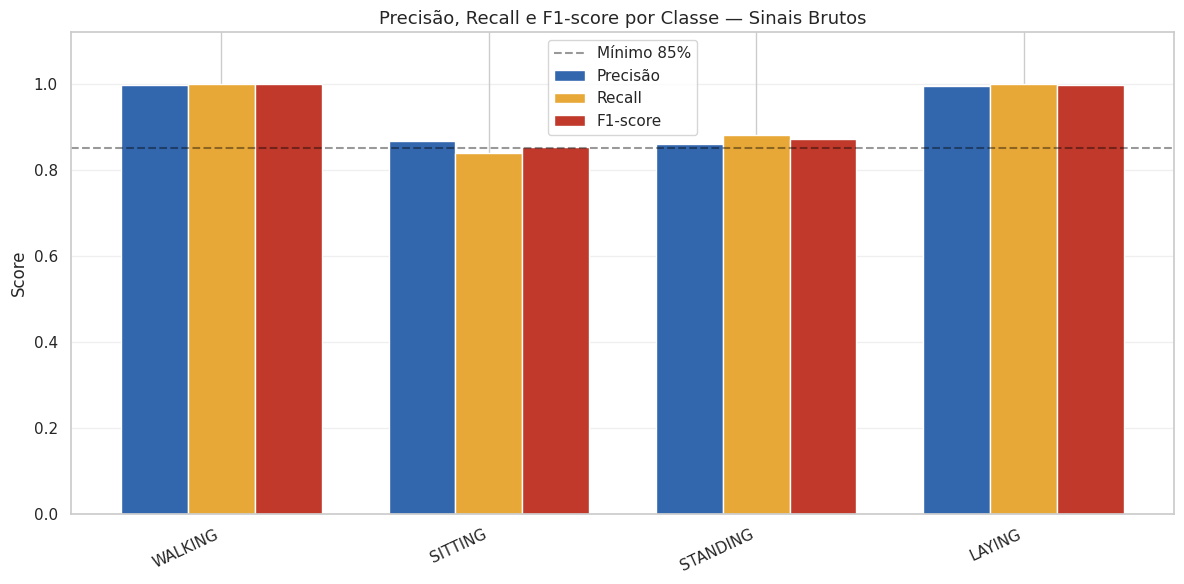

In [ ]:
prec_por_classe = precision_score(y_true, y_pred, average=None)
rec_por_classe  = recall_score(y_true, y_pred, average=None)
f1_por_classe   = f1_score(y_true, y_pred, average=None)

x_pos  = np.arange(NUM_CLASSES)
width  = 0.25
colors = ['#3266ad', '#e8a838', '#c0392b']

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x_pos - width, prec_por_classe, width, label='Precisão', color=colors[0], edgecolor='white')
ax.bar(x_pos,         rec_por_classe,  width, label='Recall',   color=colors[1], edgecolor='white')
ax.bar(x_pos + width, f1_por_classe,   width, label='F1-score', color=colors[2], edgecolor='white')

ax.axhline(y=0.85, color='black', linestyle='--', alpha=0.4, label='Mínimo 85%')
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, rotation=25, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Precisão, Recall e F1-score por Classe — Sinais Brutos', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Seção 8 — Quantização e Exportação para TensorFlow Lite

### 8.1 Converter para TFLite float32 (baseline)

In [ ]:
model.save('cnn_raw_har.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_f32 = converter.convert()

with open('cnn_raw_f32.tflite', 'wb') as f:
    f.write(tflite_f32)

size_f32 = len(tflite_f32) / 1024
print(f'TFLite float32 : {size_f32:.1f} KB')

Saved artifact at '/tmp/tmpyd75t8a4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 9), dtype=tf.float32, name='raw_signal')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137183540921360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540922512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540924240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540920976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540921552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540925200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540925392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540925584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540923472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540924816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540924048: Tens

### 8.2 Quantização INT8 completa (Post-Training Quantization)

Converte pesos e ativações de float32 para int8.
Redução esperada: ~4× no tamanho, inferência mais rápida no Cortex-M0+.

In [ ]:
def representative_dataset():
    for i in range(0, min(300, len(X_train_norm))):
        yield [X_train_norm[i:i+1]]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations                  = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset         = representative_dataset
converter_int8.target_spec.supported_ops      = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type           = tf.int8
converter_int8.inference_output_type          = tf.int8

tflite_int8 = converter_int8.convert()

with open('cnn_raw_int8.tflite', 'wb') as f:
    f.write(tflite_int8)

size_int8 = len(tflite_int8) / 1024
print(f'TFLite float32 : {size_f32:.1f} KB')
print(f'TFLite INT8    : {size_int8:.1f} KB')
print(f'Redução        : {size_f32/size_int8:.1f}× menor')
print(f'RNF2 (≤500 KB) : {"✓ ATENDIDO" if size_int8 <= 500 else "✗ NÃO ATENDIDO"}')

Saved artifact at '/tmp/tmpf1ydr6ys'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 9), dtype=tf.float32, name='raw_signal')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137183540921360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540922512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540924240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540920976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540921552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540925200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540925392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540925584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540923472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540924816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137183540924048: Tens

### 8.3 Validar acurácia do modelo quantizado

In [ ]:
def avaliar_tflite(tflite_bytes, X, y_true, label=''):
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
    interpreter.allocate_tensors()

    inp  = interpreter.get_input_details()[0]
    out  = interpreter.get_output_details()[0]
    i_scale, i_zero = inp['quantization'] if inp['dtype'] == np.int8 else (1.0, 0)

    preds = []
    for i in range(len(X)):
        sample = X[i:i+1].astype(np.float32)
        if inp['dtype'] == np.int8:
            sample = (sample / i_scale + i_zero).astype(np.int8)
        interpreter.set_tensor(inp['index'], sample)
        interpreter.invoke()
        preds.append(np.argmax(interpreter.get_tensor(out['index'])))

    acc = accuracy_score(y_true, preds)
    print(f'  {label:<20s}: {acc:.4f}  ({acc*100:.2f}%)')
    return acc

print('Avaliando modelos TFLite...')
acc_f32  = avaliar_tflite(tflite_f32,  X_test_norm, y_test, 'TFLite float32')
acc_int8 = avaliar_tflite(tflite_int8, X_test_norm, y_test, 'TFLite INT8')
print(f'  Degradação         : {(acc - acc_int8)*100:.2f} pontos percentuais')

Avaliando modelos TFLite...
  TFLite float32      : 0.9309  (93.09%)
  TFLite INT8         : 0.9173  (91.73%)
  Degradação         : 1.36 pontos percentuais


### 8.4 Gerar arquivo C para o RP2040

In [ ]:
def tflite_to_c_array(tflite_bytes, var_name='cnn_raw_har_model'):
    c_array = ', '.join([f'0x{b:02x}' for b in tflite_bytes])
    classes_str = ' '.join([f'{k}={v}' for k, v in ACTIVITY_MAP.items()])
    return f"""// Modelo CNN 1D (sinais brutos) quantizado INT8
// Tamanho : {len(tflite_bytes)} bytes ({len(tflite_bytes)/1024:.1f} KB)
// Entrada : int8 [{WINDOW_SIZE}][{N_CHANNELS}]  — 128 timesteps × 9 canais
// Saída   : int8 [{NUM_CLASSES}]  — probabilidades por classe
// Classes : {classes_str}
//
// NORMALIZAÇÃO (aplicar antes da inferência):
// Para cada canal i: valor_norm = (valor_bruto - mean[i]) / scale[i]
// mean  = {scaler.mean_.round(4).tolist()}
// scale = {scaler.scale_.round(4).tolist()}

#ifndef CNN_RAW_HAR_MODEL_H
#define CNN_RAW_HAR_MODEL_H
#include <stdint.h>
const unsigned char {var_name}[] = {{
  {c_array}
}};
const unsigned int {var_name}_len = {len(tflite_bytes)};
#endif
"""

header = tflite_to_c_array(tflite_int8)
with open('cnn_raw_har_model.h', 'w') as f:
    f.write(header)

print('✓ cnn_raw_har_model.h gerado')
print(f'  Tamanho: {len(tflite_int8)} bytes ({len(tflite_int8)/1024:.1f} KB)')
print('\nPrimeiras linhas do arquivo:')
print('\n'.join(header.split('\n')[:12]))

✓ cnn_raw_har_model.h gerado
  Tamanho: 120552 bytes (117.7 KB)

Primeiras linhas do arquivo:
// Modelo CNN 1D (sinais brutos) quantizado INT8
// Tamanho : 120552 bytes (117.7 KB)
// Entrada : int8 [128][9]  — 128 timesteps × 9 canais
// Saída   : int8 [4]  — probabilidades por classe
// Classes : 0=WALKING 1=SITTING 2=STANDING 3=LAYING
//
// NORMALIZAÇÃO (aplicar antes da inferência):
// Para cada canal i: valor_norm = (valor_bruto - mean[i]) / scale[i]
// mean  = [-0.0006, 0.0005, 0.0003, -0.0, -0.0006, 0.0029, 0.7406, 0.123, 0.1621]
// scale = [0.1121, 0.0881, 0.0747, 0.253, 0.2721, 0.1727, 0.4275, 0.4036, 0.3659]

#ifndef CNN_RAW_HAR_MODEL_H


---
## Seção 9 — Resumo Final

In [ ]:
print('╔══════════════════════════════════════════════════════════╗')
print('║     RESUMO — CNN 1D COM SINAIS BRUTOS (TinyML/HAR)       ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Entrada          : ({WINDOW_SIZE}, {N_CHANNELS}) — sinais brutos inerciais         ║')
print(f'║  Classes ({NUM_CLASSES})        : {list(ACTIVITY_MAP.values())}')
print(f'║  Arquitetura      : Conv×3 → GAP → Dense → Softmax       ║')
print(f'║  Normalização     : StandardScaler por canal              ║')
print(f'║  Épocas           : {EPOCHS} (EarlyStopping patience=10)        ║')
print(f'║  Batch size       : {BATCH_SIZE}                                      ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║                    MÉTRICAS                              ║')
print(f'║  Acurácia  (Keras float32) : {acc*100:6.2f}%                   ║')
print(f'║  Acurácia  (TFLite INT8)   : {acc_int8*100:6.2f}%                   ║')
print(f'║  Precisão  (weighted)      : {prec*100:6.2f}%                   ║')
print(f'║  Recall    (weighted)      : {rec*100:6.2f}%                   ║')
print(f'║  F1-score  (weighted)      : {f1*100:6.2f}%                   ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║                 TAMANHO DO MODELO                        ║')
print(f'║  float32   : {size_f32:7.1f} KB                               ║')
print(f'║  INT8      : {size_int8:7.1f} KB  ← para o RP2040               ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║               REQUISITOS DO SISTEMA                      ║')
print(f'║  RNF4 Acurácia ≥ 85%   : {"✓ OK" if acc_int8 >= 0.85 else "✗ FALHOU"}                           ║')
print(f'║  RNF2 Flash   ≤ 500 KB : {"✓ OK" if size_int8 <= 500 else "✗ FALHOU"}                           ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║               ARQUIVOS GERADOS                           ║')
print('║  cnn_raw_har.keras        — modelo Keras completo        ║')
print('║  cnn_raw_f32.tflite       — TFLite sem quantização       ║')
print('║  cnn_raw_int8.tflite      — TFLite INT8 para embarcado   ║')
print('║  cnn_raw_har_model.h      — array C para firmware RP2040 ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║     RESUMO — CNN 1D COM SINAIS BRUTOS (TinyML/HAR)       ║
╠══════════════════════════════════════════════════════════╣
║  Entrada          : (128, 9) — sinais brutos inerciais         ║
║  Classes (4)        : ['WALKING', 'SITTING', 'STANDING', 'LAYING']
║  Arquitetura      : Conv×3 → GAP → Dense → Softmax       ║
║  Normalização     : StandardScaler por canal              ║
║  Épocas           : 60 (EarlyStopping patience=10)        ║
║  Batch size       : 64                                      ║
╠══════════════════════════════════════════════════════════╣
║                    MÉTRICAS                              ║
║  Acurácia  (Keras float32) :  93.09%                   ║
║  Acurácia  (TFLite INT8)   :  91.73%                   ║
║  Precisão  (weighted)      :  93.08%                   ║
║  Recall    (weighted)      :  93.09%                   ║
║  F1-score  (weighted)      :  93.08%                   ║
╠══════════════